# Analysis of responses triggered by 2D visual stimuli

### 1. explain the difference between types of stimuli

In [1]:
import numpy as np
import scipy.io as sio 
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import time
from IPython import display

When describing properties of an image through its frequencies, there are two main components to consider, amplitude and phase.

Amplitude will affect the brightness/contrast of features at each level of detail, while phase will affect their placement.

White noise is defined as a signal with a flat power spectrum, i.e. equal amplitude for all frequencies.

In [2]:
def flatten_power_spectrum(image):
    """
    INPUT: square 2D array
    OUTPUT: the same array with a flattened power spectrum
    """
    # compute the fourier transform
    f_transform = np.fft.fft2(image)
    magnitude = np.abs(f_transform)
    magnitude[magnitude == 0] = 1e-8 # prevents division by 0
    # normalize the amplitudes
    f_flattened = f_transform / magnitude
    # return to space domain
    reconstructed = np.real(np.fft.ifft2(f_flattened))

    return reconstructed

def scramble_phase(image):
    """
    INPUT: square 2D array
    OUTPUT: the same array with a randomized phase spectrum
    """
    # compute the fourier transform
    f_transform = np.fft.fft2(image)
    magnitude = np.abs(f_transform)
    # generate random phases
    random_phase = np.random.uniform(-np.pi, np.pi, f_transform.shape)
    
    # combine original magnitude with random phase
    f_randomized = magnitude * np.exp(1j * random_phase)
    
    # return to space domain
    reconstructed = np.real(np.fft.ifft2(f_randomized))

    return reconstructed

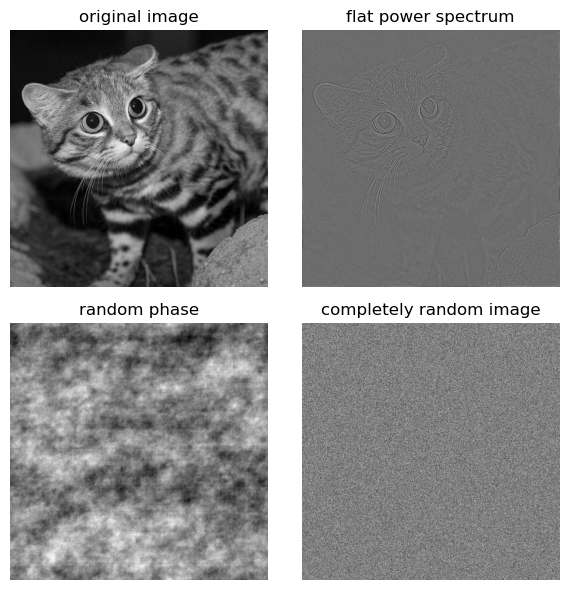

In [3]:
image = plt.imread("example_image.jpg")
# transform to grayscale
image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(6, 6))
ax1.imshow(image, cmap="gray")
ax1.set_title("original image")
ax1.axis("off")
ax2.imshow(flatten_power_spectrum(image), cmap="gray")
ax2.set_title("flat power spectrum")
ax2.axis("off")
ax3.imshow(scramble_phase(image), cmap="gray")
ax3.set_title("random phase")
ax3.axis("off")
ax4.imshow(flatten_power_spectrum(scramble_phase(image)), cmap="gray")
ax4.set_title("completely random image")
ax4.axis("off")
fig.tight_layout()

Even without amplitude information, a natural image is still recognizable.

Without phase  information, it becomes meaningless.

The image with randomized phase is still different from noise in that its power spectrum is not flat, it is identical to the original image. 

In the experiment, stimulus images that allowed for best computation of STA were flattened natural images (top right). 

We know that the visual processing system of mammals is specifically tuned to the statisical characteristics of natural images. Those properties are extremely unlikely to occur in completely random images. 

Field, D. J. (1987). Relations between the statistics of natural images and the response properties of cortical cells. Journal of the Optical Society of America A, 4, 2379.

### 2. compare firing rate for different types of stimuli

In [3]:
# file paths for the same cell, different stimuli
natural = r"crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01cequalpower_C1.sa0"

flattened = r"crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01ewhitenednatural_B1.sa0"

random_phase = r"crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01irandomphase_A1.sa0"

# time unit of 0.1ms allows for integers instead of floats, offset skips the headers
natural = np.fromfile(natural, dtype=np.int32, offset=828)
flattened = np.fromfile(flattened, dtype=np.int32, offset=828)
random_phase = np.fromfile(random_phase, dtype=np.int32, offset=828)

# extracted from the stimulus file, timepoint (in 0.1ms) when the movie stops playing
end_time = 10040000

In [71]:
# function taken from start.ipynb; we only need one of those per project so this cell will ultimately
# not be needed
def gaussian_rate_convolution(spike_times, t_start=None, t_end=None, dt=0.001, sigma=0.2):
    """
    Gaussian-smoothed firing rate using binning + convolution.

    spike_times : spike times in seconds
    dt          : bin width in seconds
    sigma       : Gaussian std in seconds

    returns:
        t        : time axis
        rate     : firing rate in spikes/s
        counts   : binned spike counts
    """
    spike_times = np.asarray(spike_times)

    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    bins = np.arange(t_start, t_end + dt, dt)
    counts, edges = np.histogram(spike_times, bins=bins)

    # Convert sigma from seconds to bins
    sigma_bins = sigma / dt

    # Smooth spike counts
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_bins,
        mode="constant"
    )

    # Convert counts/bin to spikes/second
    rate = smoothed_counts / dt

    # Bin centers
    t = edges[:-1] + dt / 2

    return t, rate, counts

In [72]:
t, r_n, _ = gaussian_rate_convolution(natural/10000, 0, end_time/10000, 0.001, 1)
_, r_f, _ = gaussian_rate_convolution(flattened/10000, 0, end_time/10000, 0.001, 1)
_, r_r, _ = gaussian_rate_convolution(random_phase/10000, 0, end_time/10000, 0.001, 1)

Text(0.5, 1.0, 'firing rates for different stimuli')

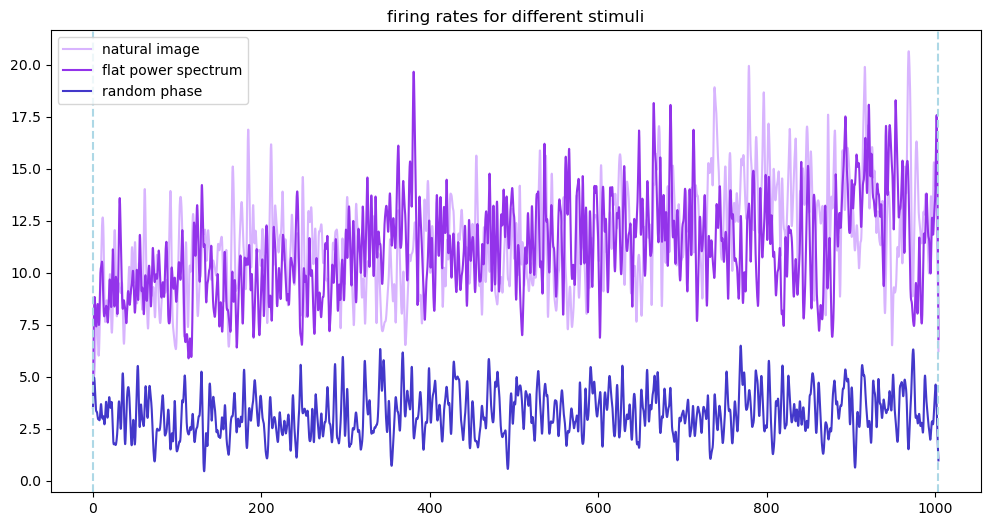

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(t, r_n, label="natural image", color="#D8B4FE")
plt.plot(t, r_f, label="flat power spectrum", color="#9333EA")
plt.plot(t, r_r, label="random phase", color="#4338CA")
plt.axvline(0, color="lightblue", linestyle='--')
plt.axvline(1004, color="lightblue", linestyle='--')
plt.legend(loc="upper left")
plt.title("firing rates for different stimuli")

The firing rate in response to random phase stimulus is significantly lower than for both natural and "whitened natural" images. It also has less variability around its mean.

### 3. compute the STA on the random stimulus

In [ ]:
"""
random phase data:

stimulus file path: crcns-pvc2/2D_noise_natural/Stimulus_Files/Randomphase_A1_25hz.mat
response file paths: crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01krandomphase_A1.sa0
                    crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\040812.A.c01\040812.A.c01irandomphase_A1.sa0

stimulus: crcns-pvc2\2D_noise_natural\Stimulus_Files\Randomphase_A3_25hz.mat
response: crcns-pvc2\2D_noise_natural\Spike_and_Log_Files\030917.A.b02\030917.A.b02grandomphase_A3.sa0

whitened data:

stimulus file path: crcns-pvc2/2D_noise_natural/Stimulus_Files/WhitenedNatural_B1_25hz.mat
response file paths: crcns-pvc2/2D_noise_natural/Spike_and_Log_Files/040812.A.c01/040812.A.c01ewhitenednatural_B1.sa0
                    crcns-pvc2/2D_noise_natural/Spike_and_Log_Files/040812.A.c01/040812.A.c01gwhitenednatural_B1.sa0
"""

In [18]:
# load data from files

response_path = r"crcns-pvc2/2D_noise_natural/Spike_and_Log_Files/040812.A.c01/040812.A.c01gwhitenednatural_B1.sa0"
spike_times = np.fromfile(response_path, dtype="<i4", offset=828) # <i4 == int32

# stimulus filename taken from from log file
stimulus_path = r'crcns-pvc2/2D_noise_natural/Stimulus_Files/WhitenedNatural_B1_25hz.mat'
# stimulus_data will be a python dictionary
stimulus_data = sio.loadmat(stimulus_path) 
images = stimulus_data['mov']
frame_count = images.shape[2] # number of frames
images = np.transpose(images, (2, 0, 1)) # new axis: frame_number, x, y
images = images - images.mean(axis=0)

In [19]:
# define parameters related to the display of stimulus
effective_frame_rate = 23.897547 # the effective refresh rate from .log file,
movie_duration = frame_count // effective_frame_rate * 10000 # unit of 0.1ms
frame_duration = 1 / effective_frame_rate
print(f"movie duration: {movie_duration} x 10**-4 s")
print(f"frame duration: {frame_duration} s")

# discard spikes that occurred after stimulus offset
spike_times = spike_times[spike_times < movie_duration]

# bin spikes by displayed frame
frame_ends_array = np.linspace(0, movie_duration, frame_count+1)
spike_counts, _ = np.histogram(spike_times, bins=frame_ends_array)
frame_numbers = np.arange(frame_count-1)
print(f"fraction of frames when no spike occurred: {(spike_counts==0).sum() / len(spike_counts)}")
print("------\nCheck for errors in data:")
print(f"no. of negative spike times: {(spike_times < 0).sum()}")
print(f"no. of duplicated spikes: {len(spike_times) - len(set(spike_times))}")

movie duration: 10040000.0 x 10**-4 s
frame duration: 0.04184529901751004 s
fraction of frames when no spike occurred: 0.7345833333333334
------
Check for errors in data:
no. of negative spike times: 0
no. of duplicated spikes: 0


In [20]:
def get_sta(frame_window:int):
    """INPUT: number of frames before spike to be considered
    OUTPUT: the computed STA of shape (frame_window, 12, 12)"""

    #initialize the returen array
    sta = np.zeros((frame_window, 12, 12))

    counts = spike_counts[frame_window-1:]
    for i, count in enumerate(counts):
        # weigh each stimulus slice by its number of spikes
        if count > 0: sta += count * images[i: (i+frame_window)]

    return sta / counts.sum()

#compare to the average sequence
def mean_sequence(frame_window:int):
    '''computes the average n-frame sub-sequence of the stimulus'''
    ret = np.zeros((frame_window, 12, 12))
    for i in range(frame_count - frame_window):
        ret += images[i:i+frame_window]
    return ret / (frame_count - frame_window)

# display the computed STA
def display_seq(seq):
    """INPUT: 3D array of (frame_number, 12, 12)
    displays the images in the same plot"""
    l = seq.shape[0]
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    im = ax.imshow(seq[0])

    for i in range(l):
        im.set_data(seq[i])
        ax.set_title(f"frame {i}")
        display.display(plt.gcf())
        display.clear_output(wait=True)
        time.sleep(0.5)

def plot_seq(seq):
    l = seq.shape[0]
    if l > 1:
        fig, axes = plt.subplots(1, l, figsize=(12,6))
        for i in range(l):
            axes[i].imshow(seq[i])
            axes[i].axis('off')
        fig.tight_layout()
    else:
        plt.imshow(seq[0])
        plt.axis('off')


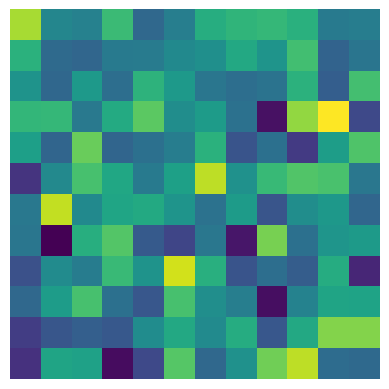

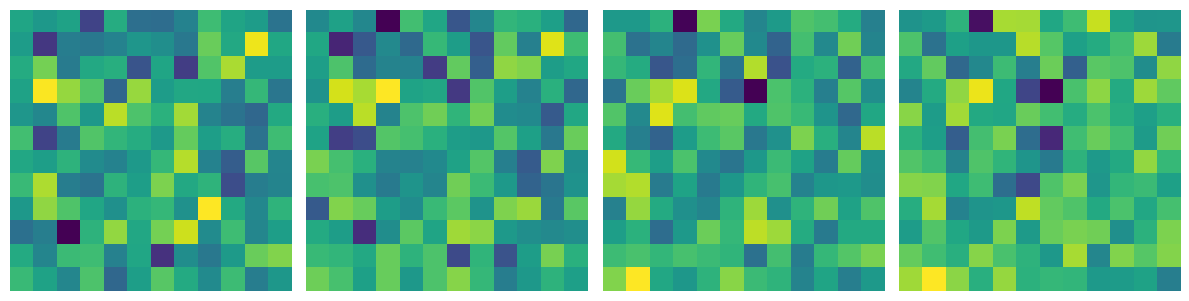

In [21]:
sta8 = get_sta(1)
#display_seq(sta8)
avg = mean_sequence(4)
#display_seq(avg)
plot_seq(sta8)
plot_seq(avg)

Conclusion from random phase:

- regardless of frame window, we have a dark blob in the middle of the image right before a spike

### 4. compare STA + nonlinear activation predictive performance 

In [ ]:
# TO DO:
# compare performance on randomphase vs whitened

In [22]:
def get_g(sta_kernel):
    """provides the spike generating signal
    by convolving the stimulus signal agiainst the STA"""

    frame_window = sta_kernel.shape[0]
    g_length = frame_count - frame_window + 1 # result of convolution without padding is shorter than the original array

    # initialize the return array, last entries will remain 0
    g = np.zeros(frame_count)
    for t in range(g_length):
        stim = images[t:(t+frame_window)].flatten()
        sta = sta_kernel.flatten()
        g[t] = np.dot(stim, sta)
    
    return g / g.std()

In [23]:
g = get_g(sta8)
# ReLU-like activation for g
# force more sparsity: g is negative about half the time, but frames with no spikes constitute 85%
# choose a threshold s.t. g will be non-zero at similar rates
g_relu = g.copy()
g_relu[g_relu<0.42] = 0
g_relu = g_relu / g_relu.max() * spike_counts.max() / 2 # rescale for plotting

# sigmoid activation for g
#g_sig = g.copy()
#g_sig = 1 / (1 + np.exp(g_sig))

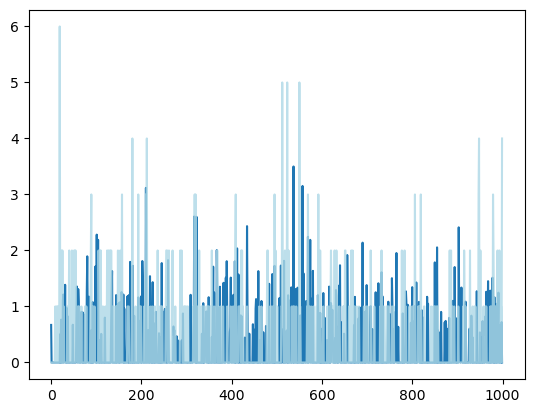

In [24]:
plt.plot(g_relu[:1000],)
plt.plot(spike_counts[:1000], color="lightblue", alpha=0.8)

In [25]:
print(np.corrcoef(g_relu, spike_counts))

[[1.        0.0559406]
 [0.0559406 1.       ]]


In [43]:
# task of predicting if a spike occured or not 
binary_label = (spike_counts > 0)
prediction_relu = (g_relu > 0)
random_guess = np.random.choice([0, 1], size=spike_counts.shape[0], p=[0.67, 0.33])
#prediction_sig = (g_sig > 0.75)

accuracy = (binary_label == prediction_relu).sum() / binary_label.shape[0]
#accuracy = (binary_label == prediction_sig).sum() / binary_label.shape[0]
guess_accuracy =  (binary_label == random_guess).sum() / binary_label.shape[0]
print(accuracy, guess_accuracy)

0.5972916666666667 0.5794583333333333


### MLP predictor

In [35]:
import tensorflow.keras as keras
from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras import Model

from keras.callbacks import ModelCheckpoint

In [ ]:
# create the dataset
X = [image.flatten() for image in images]
cutoff_id = 8*frame_count//10 # 80/20 train to test proportion
X_train = np.array(X[:cutoff_id])
y_train = binary_label[:cutoff_id]
X_test = np.array(X[cutoff_id:])
y_test = binary_label[cutoff_id:]

# defining the mlp network
in_shape = (12*12)

inp = Input(shape=in_shape)

x = Dense(in_shape//2, activation='relu')(inp)
x = Dropout(0.5)(x)
x = Dense(in_shape//4, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inp, outputs=out, name="mlp-spike-predictor")\
lr = 0.001
optim = Adam(learning_rate=lr)
loss_fn = BinaryCrossentropy()

model.compile(optimizer=optim, loss=loss_fn, metrics=['accuracy'])
checkpoint = ModelCheckpoint(filepath='best_mlp.h5', monitor='val_loss', save_best_only=True)
model.fit(X_train, y_train, batch_size=4, epochs=3, validation_data=(X_test, y_test))

#accuracy of 0.65